## Process Mining Using Python

PM4PY is a python library for process mining.  This notebook can be copied and repurposed with your own CSV files.

In [1]:
# Install the process mining code library for python.
!pip install pm4py -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 15.1 MB/s eta 0:00:00


In [2]:
# Load the required code libraries.
import pm4py   # for process mining
import pandas  # for loading files
import io      # for loading files

In [3]:
# Select where the data file is located on our local drive.
# NOTE:  If you reload the data, it may add a number to the filename.
from google.colab import files
uploaded = files.upload()

Saving order_to_cash.csv to order_to_cash.csv


In [4]:
# Load the data (CSV file).
# NOTE: Change the filename to reflect your own.
event_log = pandas.read_csv(io.BytesIO(uploaded['order_to_cash.csv']))

In [ ]:
# Preview the first few records of data.
event_log.head(100)

In [13]:
# List all fields and their data types.
event_log.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33615 entries, 0 to 33614
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   case_id    33615 non-null  int64         
 1   activity   33615 non-null  object        
 2   timestamp  33615 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 788.0+ KB


In [9]:
# Convert the timestamp.
event_log['timestamp'] = pandas.to_datetime(event_log['timestamp'], format='%d.%m.%Y %H:%M:%S')
event_log.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33615 entries, 0 to 33614
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   case_id    33615 non-null  int64         
 1   activity   33615 non-null  object        
 2   timestamp  33615 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 788.0+ KB


In [18]:
# Calculate the number of cases and activities.
# NOTE: Change 'case_id' in the second line below to the field name in your file.
num_activities = len(event_log)
num_cases = len(event_log.case_id.unique())
print("Activities: {} \n Cases: {}".format(num_activities, num_cases))

Activities: 33615 
 Cases: 5047


In [14]:
# Identify unique activities
event_log['activity'].unique()

array(['Sales Order Created', 'Payment Received', 'Invoice Created',
       'Confirmed Delivery Date', 'Delivery Completed', 'Shipment Sent',
       'Customer pick-up', 'Picking Done', 'Delivery Changed',
       'Purchase Order Created', 'Confirmation of Service',
       'Request for Quotation'], dtype=object)

In [20]:
distinct_activities = len(event_log['activity'].unique())
print("Distinct activities: {}".format(distinct_activities))

Distinct activities: 12


In [26]:
from numpy import median
throughput_time_seconds_= pm4py.get_all_case_durations(event_log)
median_throughput_time_seconds = median(throughput_time_seconds_)
print("Median throughput time in seconds: {}".format(median_throughput_time_seconds))

# convert to days
# 86400 seconds in a day
median_throughput_time_days = round(median_throughput_time_seconds / 86400, 0)
print("Median throughput time in days: {}".format(median_throughput_time_days))

Median throughput time in seconds: 2039867.0
Median throughput time in days: 24.0


In [15]:
# Identify start and end activities.
# NOTE: Change the field names in single quotes to reflect those in your file.
event_log = pm4py.format_dataframe(event_log, case_id='case_id', activity_key='activity', timestamp_key='timestamp')
start_activities = pm4py.get_start_activities(event_log)
end_activities = pm4py.get_end_activities(event_log)
print("Start activities: {} \n End activities: {}".format(start_activities, end_activities))

Start activities: {'Sales Order Created': 4951, 'Delivery Completed': 1, 'Request for Quotation': 95} 
 End activities: {'Payment Received': 4532, 'Invoice Created': 124, 'Confirmed Delivery Date': 176, 'Picking Done': 10, 'Delivery Completed': 202, 'Sales Order Created': 2, 'Purchase Order Created': 1}


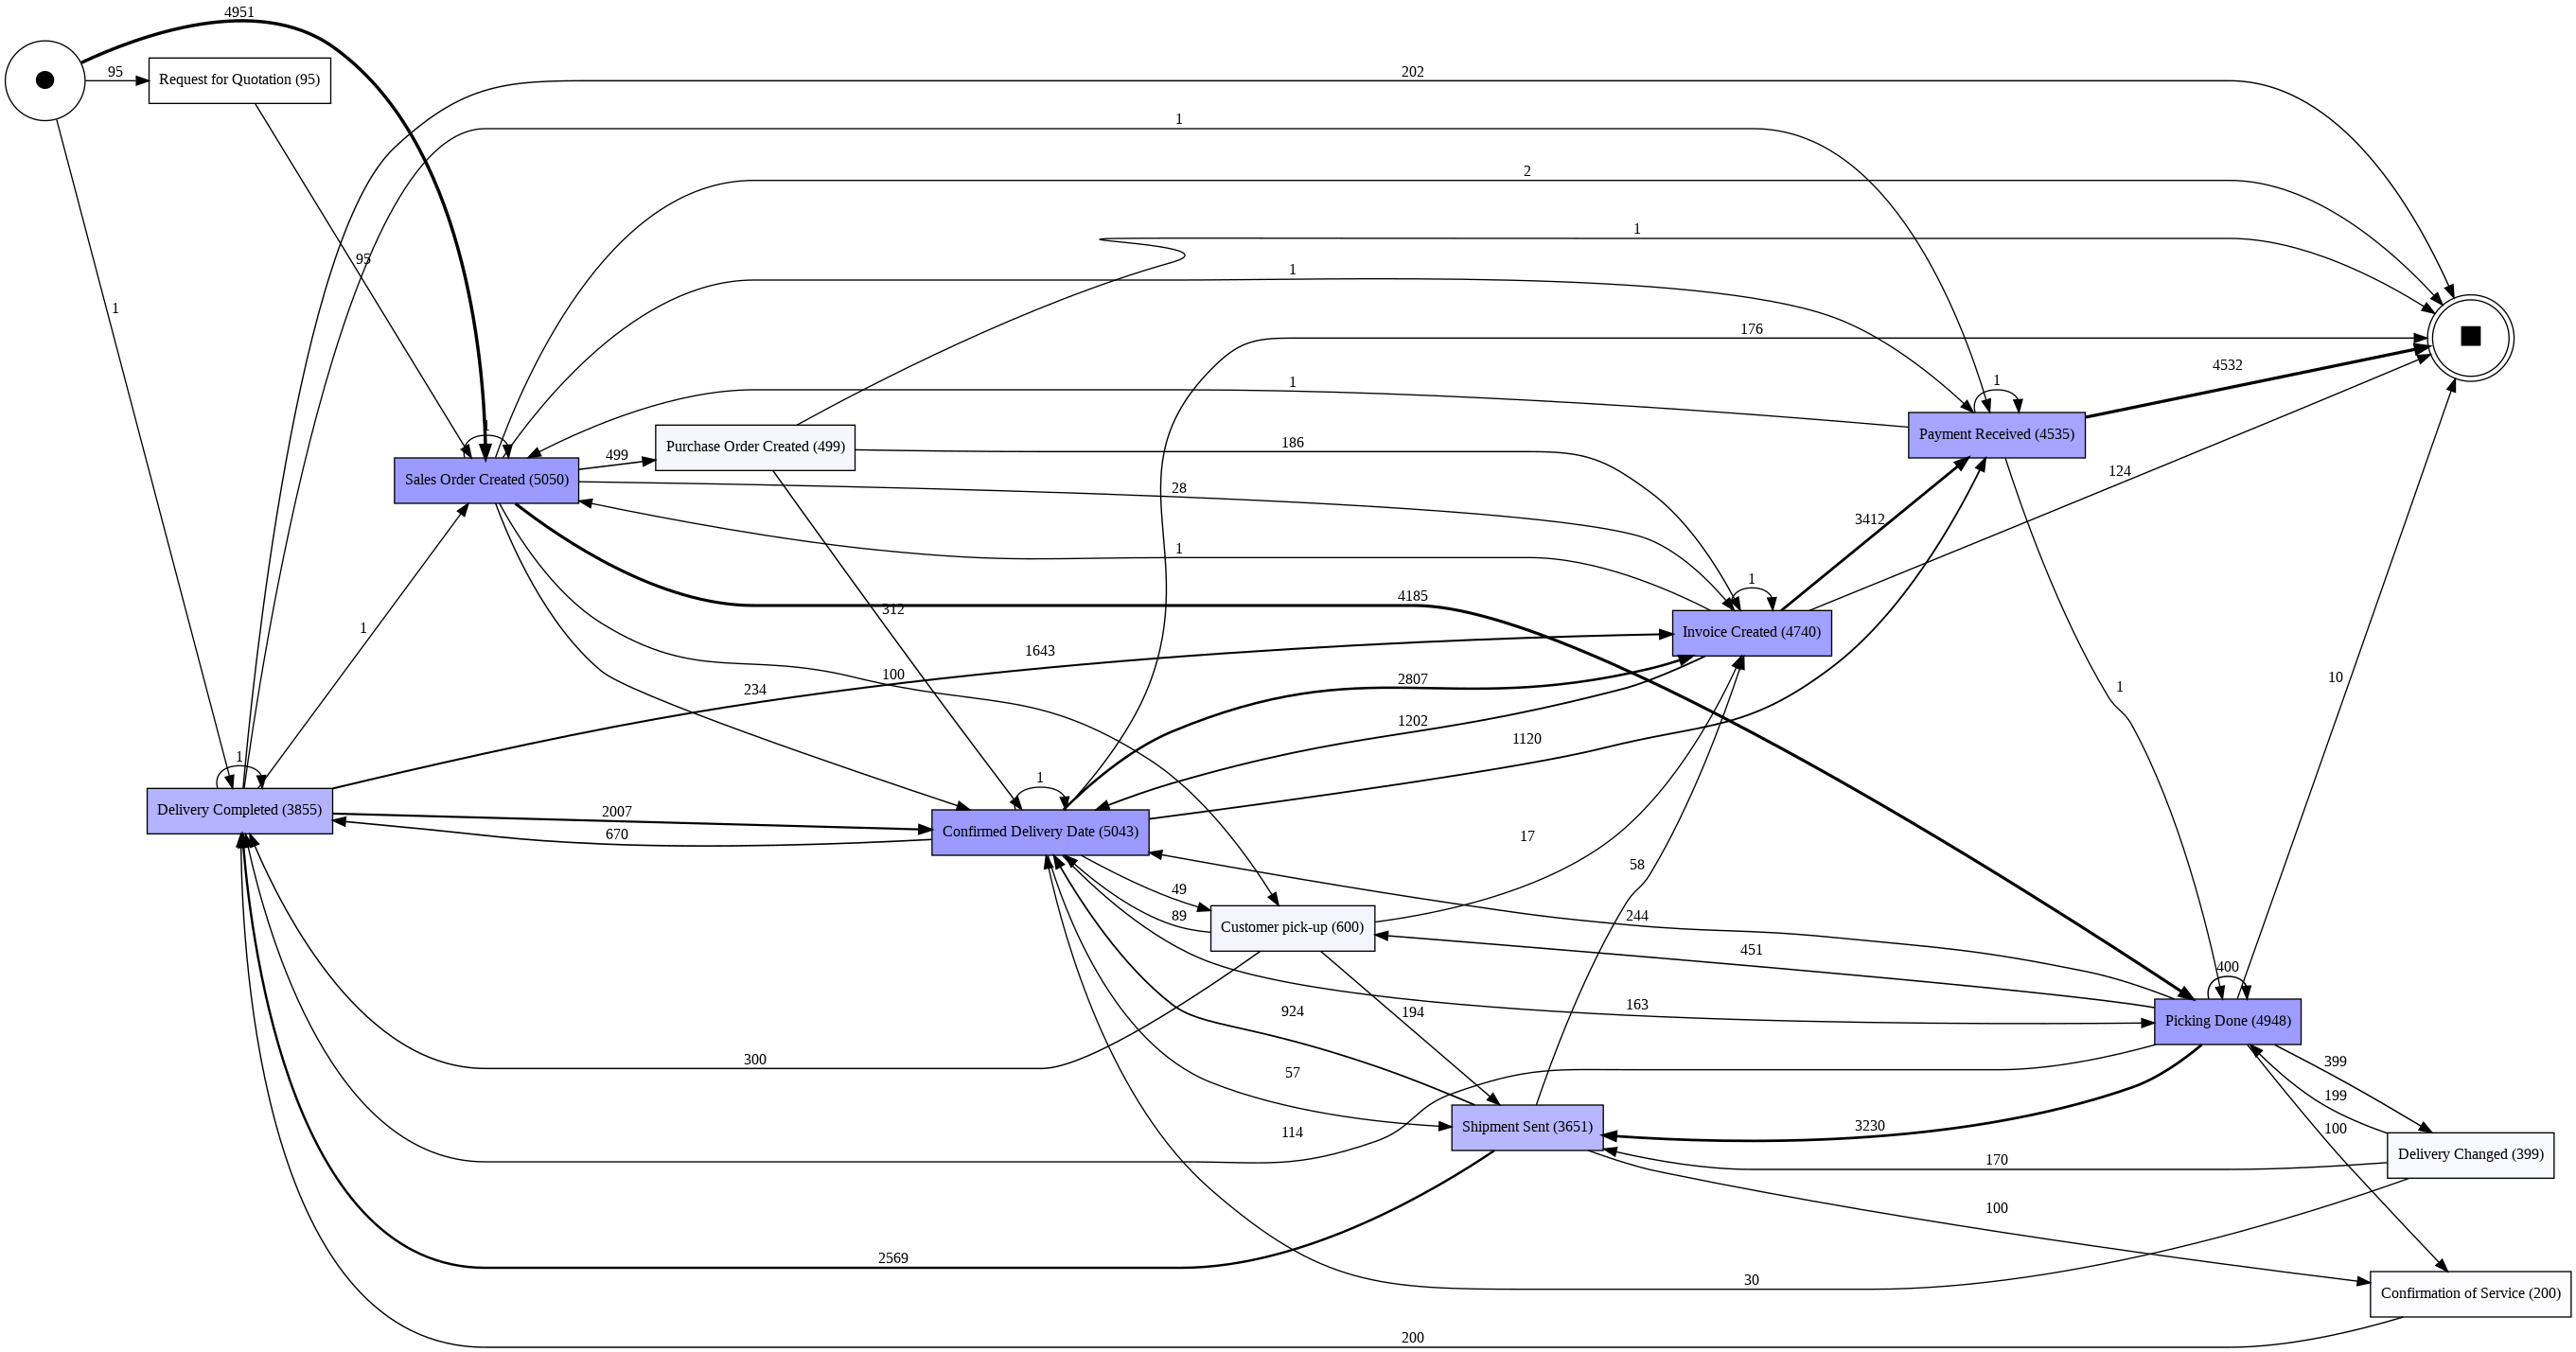

In [16]:
# Generate the DFG process map ("directly follows graph").
dfg, start_activities, end_activities = pm4py.discover_dfg(event_log)
pm4py.view_dfg(dfg, start_activities, end_activities)

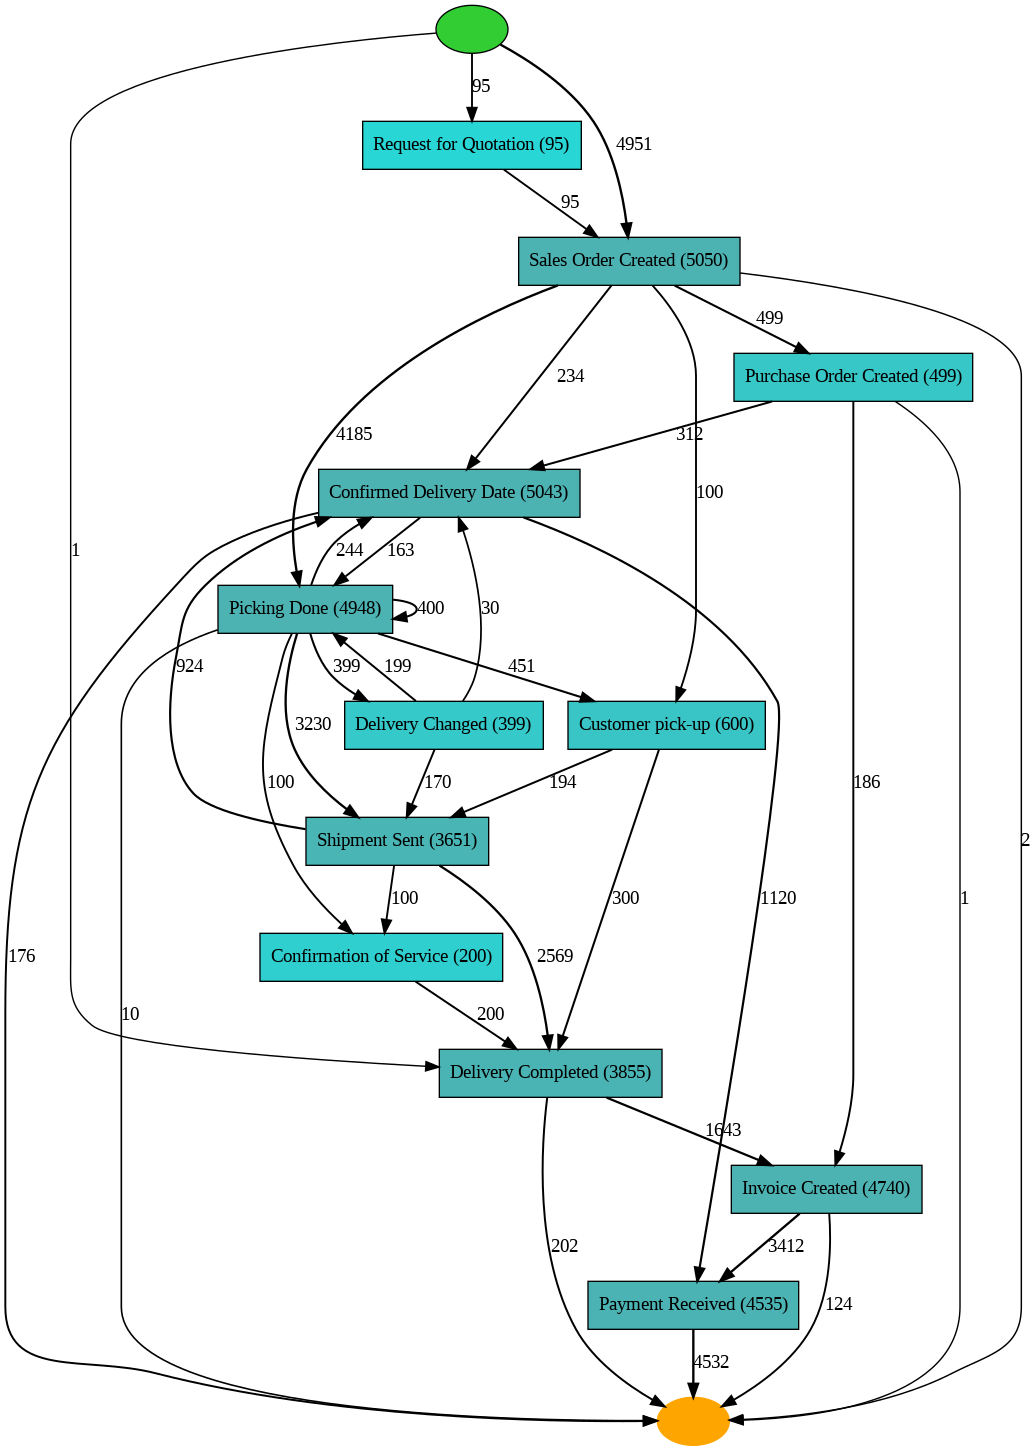

In [17]:
# Generate the HM process map ("heuristics miner").
# Simplifies the flow and removes some of the noise.
map = pm4py.discover_heuristics_net(event_log)
pm4py.view_heuristics_net(map)